# How a simulated source is drawn: $P(\Omega, d, \theta)$ straight from the PE

Every iteration of the upper-limit simulation injects **one possible GW source**. A source is four numbers:

| symbol | meaning |
|---|---|
| $\Omega = (\mathrm{RA}, \mathrm{Dec})$ | where in the sky |
| $d$ | luminosity distance |
| $\theta$ | jet viewing angle $\theta_\mathrm{v} = \min(\theta_{JN},\,180^\circ-\theta_{JN})$ |

This notebook only shows **how those four numbers are chosen**. It does not simulate observations.
It compares two recipes:

* **old:** $\;\Omega \sim P(\Omega)$ from the skymap $\;\to\; d \sim P(d\mid\Omega)$ from the skymap $\;\to\; \theta \sim P(\theta\mid d)$ from the PE
* **new (default):** $\;$ pick **one row** of the PE posterior table at random and take its $(\Omega, d, \theta)$ **together**

Sections:

1. What the PE posterior is, concretely (a table)
2. The new recipe, step by step
3. The chain rule: why the old recipe is "almost" right, and where it fails
4. The hidden assumption $P(\theta\mid d,\Omega) \to P(\theta\mid d)$, on a toy example
5. All the options in the simulation, in one table

Background reading: [`docs/viewing_angle_distribution.md`](../docs/viewing_angle_distribution.md) (§8, §11).
Code: `gwuls.simulate.sample_sky_distance_angle_pe` and `gwuls.simulate.sample_injections_3d`.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
import healpy as hp
from gammapy.maps import WcsGeom

from gwuls import gw_pe, paths, simulate, angle_distribution as angdist

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
C_PE, C_OLD, C_MID, C_IND = "#2b6cb0", "#c0392b", "#d68910", "#7f8c8d"   # one colour per recipe

**Parameters.** The event and the analysis geometry are the same as in
`sim_3d_model_CTAO_paper_pe_joint.ipynb`.

In [2]:
source_name  = "S240615dg"
source_coord = SkyCoord(ra=7.53, dec=45.81, unit="deg")   # centre of the analysis geometry
binsz        = 0.08                                       # deg, sky bin size
geom_width   = 2.5 * 1.43                                 # deg, same as the main notebook

N_DRAW = 20_000          # number of simulated sources drawn with each recipe
rng = np.random.default_rng(1)

### The two recipes at a glance

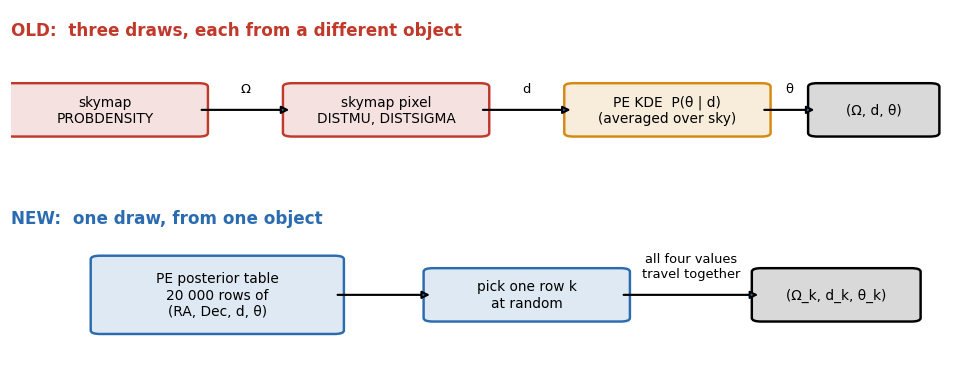

In [3]:
def box(ax, x, y, text, color, w=0.2, h=0.13):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h, boxstyle="round,pad=0.01",
                                fc=color, ec="none", alpha=0.15))
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h, boxstyle="round,pad=0.01",
                                fc="none", ec=color, lw=1.6))
    ax.text(x, y, text, ha="center", va="center", fontsize=9)

def arrow(ax, x0, x1, y, label=""):
    ax.annotate("", xy=(x1, y), xytext=(x0, y), arrowprops=dict(arrowstyle="-|>", lw=1.4))
    if label:
        ax.text((x0 + x1) / 2, y + 0.05, label, ha="center", fontsize=8.5)

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

ax.text(0.0, 0.93, "OLD:  three draws, each from a different object", fontsize=11, weight="bold", color=C_OLD)
box(ax, 0.10, 0.72, "skymap\nPROBDENSITY", C_OLD)
box(ax, 0.40, 0.72, "skymap pixel\nDISTMU, DISTSIGMA", C_OLD)
box(ax, 0.70, 0.72, "PE KDE  P(θ | d)\n(averaged over sky)", C_MID)
box(ax, 0.92, 0.72, "(Ω, d, θ)", "k", w=0.12)
arrow(ax, 0.20, 0.30, 0.72, "Ω")
arrow(ax, 0.50, 0.60, 0.72, "d")
arrow(ax, 0.80, 0.86, 0.72, "θ")

ax.text(0.0, 0.40, "NEW:  one draw, from one object", fontsize=11, weight="bold", color=C_PE)
box(ax, 0.22, 0.20, "PE posterior table\n20 000 rows of\n(RA, Dec, d, θ)", C_PE, w=0.25, h=0.2)
box(ax, 0.55, 0.20, "pick one row k\nat random", C_PE)
box(ax, 0.88, 0.20, "(Ω_k, d_k, θ_k)", "k", w=0.16)
arrow(ax, 0.345, 0.45, 0.20)
arrow(ax, 0.65, 0.80, 0.20, "all four values\ntravel together")
plt.show()

---
## 1. What the PE posterior is, concretely

Parameter estimation (PE) does not give us a formula for $P(\Omega, d, \theta \mid \text{data})$.
It gives us **samples**: a long table where every row is one source that is compatible with the GW data.
For a GWTC release, the standardized file keeps 5000 rows from each of the 4 waveform analyses, so
20 000 rows in total (see `gwuls/gw_pe.py`).

The key idea: **the table *is* the distribution.** Regions of parameter space where the GW data
are more likely have more rows. A probability is a fraction of rows:

$$
P\big((\Omega, d, \theta) \in R\big) \;\approx\; \frac{\#\{\text{rows inside } R\}}{\#\{\text{all rows}\}} .
$$

In [4]:
pe = gw_pe.load_pe(source_name)
table = {
    "ra_deg":       pe.get("ra_deg"),
    "dec_deg":      pe.get("dec_deg"),
    "distance_Mpc": pe.get("distance_Mpc"),
    "theta_deg":    pe.get("viewing_angle_deg"),   # folded jet angle, in [0, 90] deg
}
n_rows = table["distance_Mpc"].size
print(f"{source_name}: {n_rows} rows, analyses = {pe.analyses}\n")
print(f"{'row':>5} | {'RA [deg]':>8} {'Dec [deg]':>9} {'d [Mpc]':>8} {'theta [deg]':>11}")
print("-" * 50)
for k in range(8):
    print(f"{k:5d} | {table['ra_deg'][k]:8.2f} {table['dec_deg'][k]:9.2f} "
          f"{table['distance_Mpc'][k]:8.0f} {table['theta_deg'][k]:11.1f}")
print("  ... |")

S240615dg: 20000 rows, analyses = ('C00:IMRPhenomXPHM-SpinTaylor', 'C00:IMRPhenomXPNR', 'C00:NRSur7dq4', 'C00:SEOBNRv5PHM')

  row | RA [deg] Dec [deg]  d [Mpc] theta [deg]
--------------------------------------------------
    0 |     9.28     47.59     1347        15.8
    1 |     5.75     46.93     1754        14.6
    2 |     5.72     44.17     1252        53.1
    3 |    10.10     46.73     1525        22.3
    4 |    10.21     44.12     1206        49.9
    5 |    10.94     46.45      754        80.3
    6 |     5.76     47.14     1641        32.8
    7 |     5.96     46.18     1515        15.8
  ... |


Here is the same table drawn as a picture. Every dot is one row. In panel (d) the dots are coloured by
distance, and the **same colours** are used for the sky in panel (a).

2 rows lie far from the main sky mode (not shown in the sky panels)


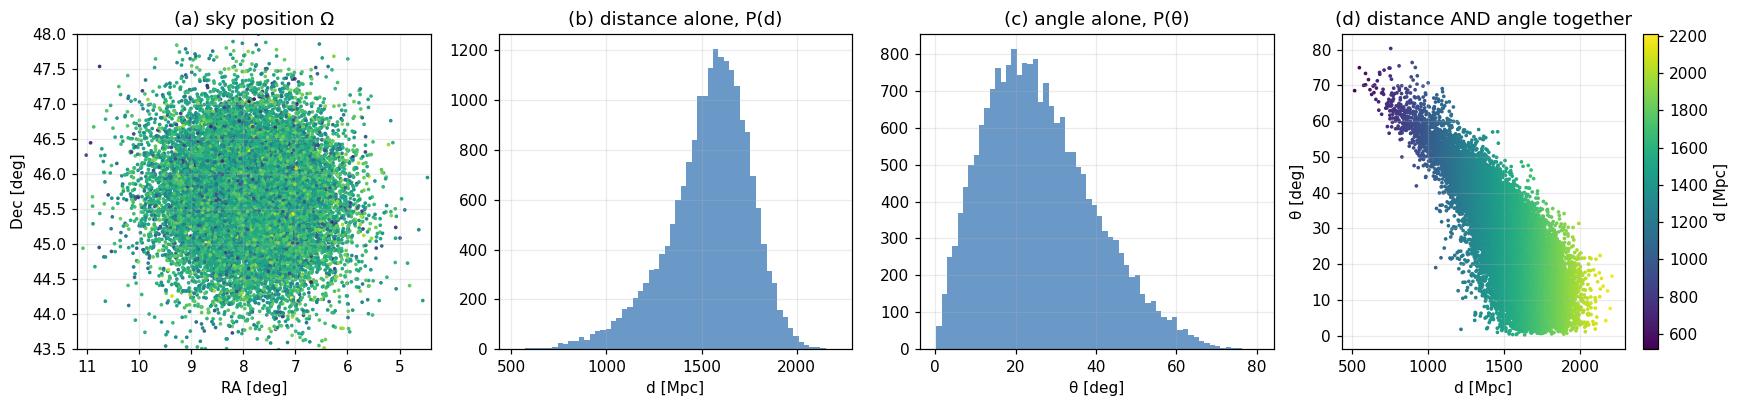

correlation(d, cos θ) = 0.82


In [5]:
ra, dec, d, th = (table[k] for k in ("ra_deg", "dec_deg", "distance_Mpc", "theta_deg"))
main = np.hypot((ra - 7.8) * np.cos(np.radians(45.7)), dec - 45.7) < 5      # main sky mode
print(f"{(~main).sum()} rows lie far from the main sky mode (not shown in the sky panels)")
SKY_LIM = dict(xlim=(11.2, 4.4), ylim=(43.5, 48.0))

fig, axs = plt.subplots(1, 4, figsize=(16, 3.8))
sc = axs[0].scatter(ra, dec, c=d, s=2, cmap="viridis")
axs[0].set(xlabel="RA [deg]", ylabel="Dec [deg]", title="(a) sky position Ω", **SKY_LIM)
axs[1].hist(d, 60, color=C_PE, alpha=0.7); axs[1].set(xlabel="d [Mpc]", title="(b) distance alone, P(d)")
axs[2].hist(th, 60, color=C_PE, alpha=0.7); axs[2].set(xlabel="θ [deg]", title="(c) angle alone, P(θ)")
axs[3].scatter(d, th, c=d, s=2, cmap="viridis")
axs[3].set(xlabel="d [Mpc]", ylabel="θ [deg]", title="(d) distance AND angle together")
plt.colorbar(sc, ax=axs[3], label="d [Mpc]")
plt.tight_layout(); plt.show()

print(f"correlation(d, cos θ) = {np.corrcoef(d, np.cos(np.radians(th)))[0, 1]:.2f}")

**Panel (d) is the important one.** Distance and angle are strongly linked: a **far** source must be
nearly **face-on** (small $\theta$), and a **near** source must be **inclined** (large $\theta$).
The GW amplitude measures roughly $(\text{orientation factor})/d$, so the two trade off against each other.
This is the *distance–inclination degeneracy*.

Panels (b) and (c) are the 1D marginals. On their own they **lose** this link. Any recipe that draws
$d$ and $\theta$ separately has to rebuild the link from somewhere. That is the whole story of this notebook.

---
## 2. The new recipe, step by step

What `simulate.sample_sky_distance_angle_pe` does, in three steps.

### Step 1: keep only rows that fall inside the analysis geometry

The simulation can only inject a source into a sky bin that exists in the map. Rows outside the map
(or outside the optional `sky_mask`, e.g. the 95% region) are dropped.

19683 of 20000 rows (98.4%) are inside the analysis geometry


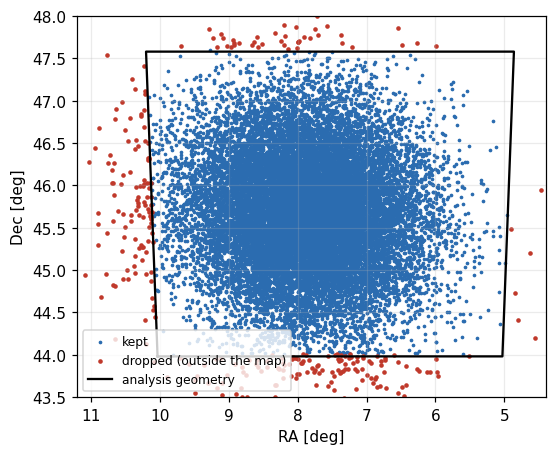

In [6]:
geom = WcsGeom.create(skydir=source_coord, binsz=binsz, width=(geom_width, geom_width), frame="icrs")
geom_image = geom.to_image()
bin_c = geom_image.get_coord()
bin_c_ra, bin_c_dec = bin_c.lon.to_value(u.deg), bin_c.lat.to_value(u.deg)

ix, iy = (np.asarray(i, int) for i in geom_image.coord_to_idx(SkyCoord(ra * u.deg, dec * u.deg)))
inside = (ix >= 0) & (iy >= 0)
print(f"{inside.sum()} of {n_rows} rows ({inside.mean():.1%}) are inside the analysis geometry")

ny, nx = geom_image.data_shape
corners = geom_image.wcs.pixel_to_world([-0.5, nx - 0.5, nx - 0.5, -0.5, -0.5],
                                        [-0.5, -0.5, ny - 0.5, ny - 0.5, -0.5])
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(ra[inside], dec[inside], s=2, c=C_PE, label="kept")
ax.scatter(ra[~inside], dec[~inside], s=4, c=C_OLD, label="dropped (outside the map)")
ax.plot(corners.ra.deg, corners.dec.deg, "k-", lw=1.5, label="analysis geometry")
ax.set(xlabel="RA [deg]", ylabel="Dec [deg]", **SKY_LIM); ax.legend(loc="lower left", fontsize=8)
plt.show()

Dropping rows is the same as **conditioning** the posterior on "the source is inside the map":
$P(\Omega, d, \theta \mid \Omega \in \text{map})$. The old route did the same thing when it renormalised
the skymap probability over the map.

### Step 2: pick rows at random, all with the same probability

$k \sim \text{Uniform}\{\text{kept rows}\}$, then source $= (\Omega_k, d_k, \theta_k)$.
Below, six picks are highlighted. Each pick has **one colour** in both panels, which shows that the sky
position, the distance and the angle all come from the **same row**.

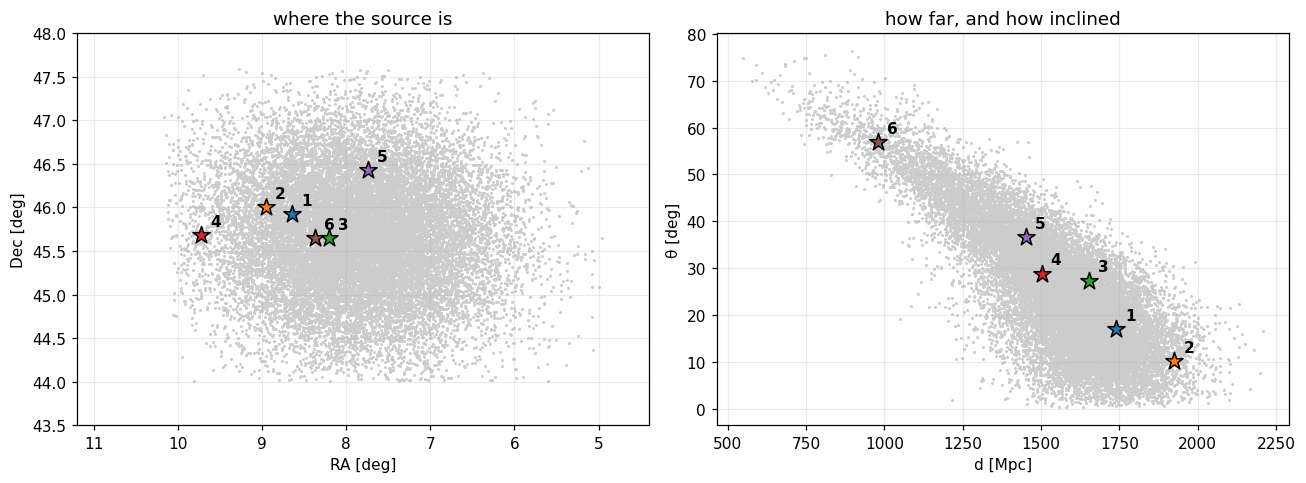

pick  row k |      RA     Dec  d [Mpc]  θ [deg]
   1   9495 |    8.65   45.93     1740     17.0
   2  10270 |    8.96   46.00     1925     10.2
   3  15138 |    8.20   45.65     1653     27.3
   4  19024 |    9.72   45.68     1502     28.8
   5    718 |    7.75   46.43     1452     36.6
   6   2899 |    8.37   45.65      980     56.9


In [7]:
kept = np.flatnonzero(inside)
picks = kept[rng.integers(0, kept.size, 6)]
colors = plt.cm.tab10(np.arange(6))

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
axs[0].scatter(ra[kept], dec[kept], s=1, c="0.8")
axs[1].scatter(d[kept], th[kept], s=1, c="0.8")
for n, (k, c) in enumerate(zip(picks, colors), 1):
    axs[0].scatter(ra[k], dec[k], s=140, color=c, marker="*", ec="k", zorder=3)
    axs[0].annotate(str(n), (ra[k], dec[k]), xytext=(6, 6), textcoords="offset points", weight="bold")
    axs[1].scatter(d[k], th[k], s=140, color=c, marker="*", ec="k", zorder=3)
    axs[1].annotate(str(n), (d[k], th[k]), xytext=(6, 6), textcoords="offset points", weight="bold")
axs[0].set(xlabel="RA [deg]", ylabel="Dec [deg]", title="where the source is", **SKY_LIM)
axs[1].set(xlabel="d [Mpc]", ylabel="θ [deg]", title="how far, and how inclined")
plt.tight_layout(); plt.show()

print(f"{'pick':>4} {'row k':>6} | {'RA':>7} {'Dec':>7} {'d [Mpc]':>8} {'θ [deg]':>8}")
for n, k in enumerate(picks, 1):
    print(f"{n:4d} {k:6d} | {ra[k]:7.2f} {dec[k]:7.2f} {d[k]:8.0f} {th[k]:8.1f}")

### Step 3: put the source at the centre of its sky bin

The simulation works on a map of bins (0.08° here), so the source is injected at the **centre of the
bin** its row falls in (black outline). This is the same snapping the skymap route does. $d_k$ and $\theta_k$ are used
exactly as they are.

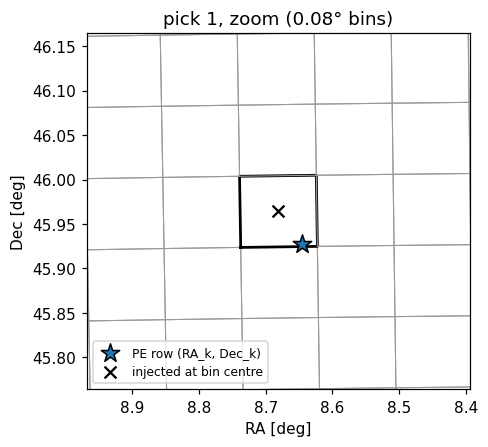

In [8]:
k = picks[0]
cra, cdec = bin_c_ra[iy[k], ix[k]], bin_c_dec[iy[k], ix[k]]
w_ra = binsz / np.cos(np.radians(cdec))          # bin width in RA degrees at this Dec
fig, ax = plt.subplots(figsize=(4.5, 4.2))
for j in range(max(iy[k] - 3, 0), min(iy[k] + 4, ny)):
    for i in range(max(ix[k] - 3, 0), min(ix[k] + 4, nx)):
        c = geom_image.wcs.pixel_to_world(i + np.array([-.5, .5, .5, -.5, -.5]), j + np.array([-.5, -.5, .5, .5, -.5]))
        ax.plot(c.ra.deg, c.dec.deg, color="0.6" if (i, j) != (ix[k], iy[k]) else "k", lw=0.7 if (i, j) != (ix[k], iy[k]) else 1.8)
ax.scatter(ra[k], dec[k], s=160, marker="*", color=colors[0], ec="k", zorder=3, label="PE row (RA_k, Dec_k)")
ax.scatter(cra, cdec, s=60, marker="x", color="k", zorder=3, label="injected at bin centre")
ax.set_xlim(cra + 2.5 * w_ra, cra - 2.5 * w_ra); ax.set_ylim(cdec - 2.5 * binsz, cdec + 2.5 * binsz)
ax.set(xlabel="RA [deg]", ylabel="Dec [deg]", title=f"pick 1, zoom ({binsz}° bins)")
ax.legend(fontsize=8, loc="lower left"); ax.grid(False)
plt.show()

### The production function does exactly this

Here the real sampler `simulate.sample_sky_distance_angle_pe` is called, and its $N$ draws are
compared with the PE table. **No density is estimated and no formula is fitted.** That is why the draws
reproduce the posterior, including the $d$–$\theta$ link, up to resampling noise.

Why is "pick a random row" the same as "draw from $P(\Omega, d, \theta)$"? A region that holds 10% of
the rows is picked 10% of the time, and by Section 1 that is its probability. This holds for **any**
region of the 4D space, so it holds for the full joint and for every correlation in it.

draws reuse 19683 distinct rows; keys: ['d_sim', 'dec', 'dec_pe', 'frac_pe_support', 'ix', 'iy', 'n_pe_support', 'pe_index', 'ra', 'ra_pe', 'theta_sim']


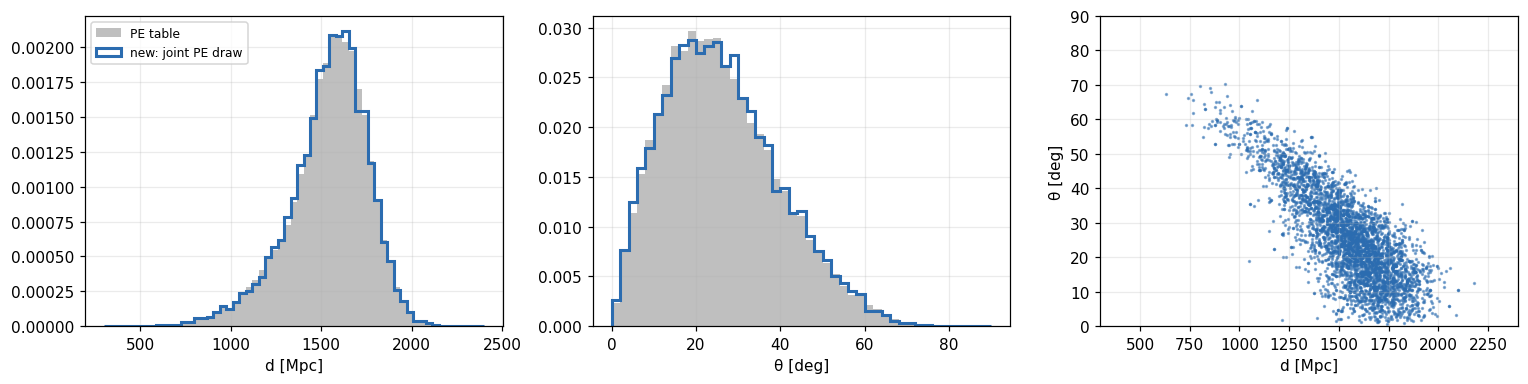

In [9]:
draw_new = simulate.sample_sky_distance_angle_pe(table, geom, bin_c_ra, bin_c_dec, N_DRAW, rng)
print(f"draws reuse {draw_new['n_pe_support']} distinct rows; keys: {sorted(draw_new)}")

def compare(ax_row, dd, tt, color, label, ref=(d[kept], th[kept])):
    bins_d, bins_t = np.linspace(300, 2400, 60), np.linspace(0, 90, 46)
    ax_row[0].hist(ref[0], bins_d, density=True, color="0.75", label="PE table")
    ax_row[0].hist(dd, bins_d, density=True, histtype="step", lw=2, color=color, label=label)
    ax_row[1].hist(ref[1], bins_t, density=True, color="0.75")
    ax_row[1].hist(tt, bins_t, density=True, histtype="step", lw=2, color=color)
    ax_row[2].scatter(dd[:4000], tt[:4000], s=1.5, color=color, alpha=0.5)
    ax_row[2].set_xlim(300, 2400); ax_row[2].set_ylim(0, 90)
    ax_row[0].set(xlabel="d [Mpc]"); ax_row[1].set(xlabel="θ [deg]"); ax_row[2].set(xlabel="d [Mpc]", ylabel="θ [deg]")
    ax_row[0].legend(fontsize=8)

fig, axs = plt.subplots(1, 3, figsize=(14, 3.6))
compare(axs, draw_new["d_sim"], draw_new["theta_sim"], C_PE, "new: joint PE draw")
plt.tight_layout(); plt.show()

---
## 3. The chain rule: why the old recipe is "almost" right

Any joint distribution can be split into conditionals. This is **exact**:

$$
P(\Omega, d, \theta) \;=\; P(\Omega)\;\cdot\;P(d \mid \Omega)\;\cdot\;P(\theta \mid d, \Omega).
$$

So drawing $\Omega$, then $d$ given $\Omega$, then $\theta$ given $d$ **and** $\Omega$ is a correct
way to draw from the joint. Picking a PE row does exactly this, implicitly. A row is a draw of all three
factors at once, all from the same posterior.

The old recipe followed the same chain, but each factor came **from a different place**:

| factor | correct source | old recipe used | what goes wrong |
|---|---|---|---|
| $P(\Omega)$ | PE posterior | alert skymap `PROBDENSITY` | low-latency analysis, slightly different |
| $P(d\mid\Omega)$ | PE posterior | skymap per-pixel ansatz (`DISTMU`, `DISTSIGMA`) | **different distances** (closer, for this event) |
| $P(\theta\mid d,\Omega)$ | PE posterior, *at that sky position* | $P(\theta\mid d)$: a KDE of the PE, averaged over the whole sky | drops $\Omega$ from the condition (Section 4) |

The third factor is the "not fully correct" part of $P(\Omega)P(d\mid\Omega)P(\theta\mid d)$: it should
be $P(\theta\mid d, \Omega)$. The second factor, in practice, did even more damage: through the
degeneracy, a wrong distance becomes a wrong angle.

Below, four recipes are run side by side on the same event. Each one changes one factor:

| | $\Omega$, $d$ from | $\theta$ from | in the simulation |
|---|---|---|---|
| **A** | PE row | the same PE row | `SKY_DISTANCE_MODE="pe"`, `THETA_MODE="pe"` (**default**) |
| **B** | PE row | $P(\theta\mid d)$ KDE (sky-averaged) | `"pe"`, `"gw"` |
| **C** | skymap | $P(\theta\mid d)$ KDE (sky-averaged) | `"skymap"`, `"gw"` (**old**) |
| **D** | skymap | $P(\theta)$, ignoring $d$ | `"skymap"` + any $d$-independent prior |

To keep it simple, this comparison uses the whole sky (no analysis geometry).

**The skymap draw** (recipes C and D), written out:

1. pick a pixel with probability $\propto$ `PROBDENSITY` $\times$ pixel area,
2. draw $d$ from that pixel's ansatz $\;p(d\mid\text{pixel}) \propto d^2\,\exp\!\big[-(d-\mu)^2/2\sigma^2\big]$.

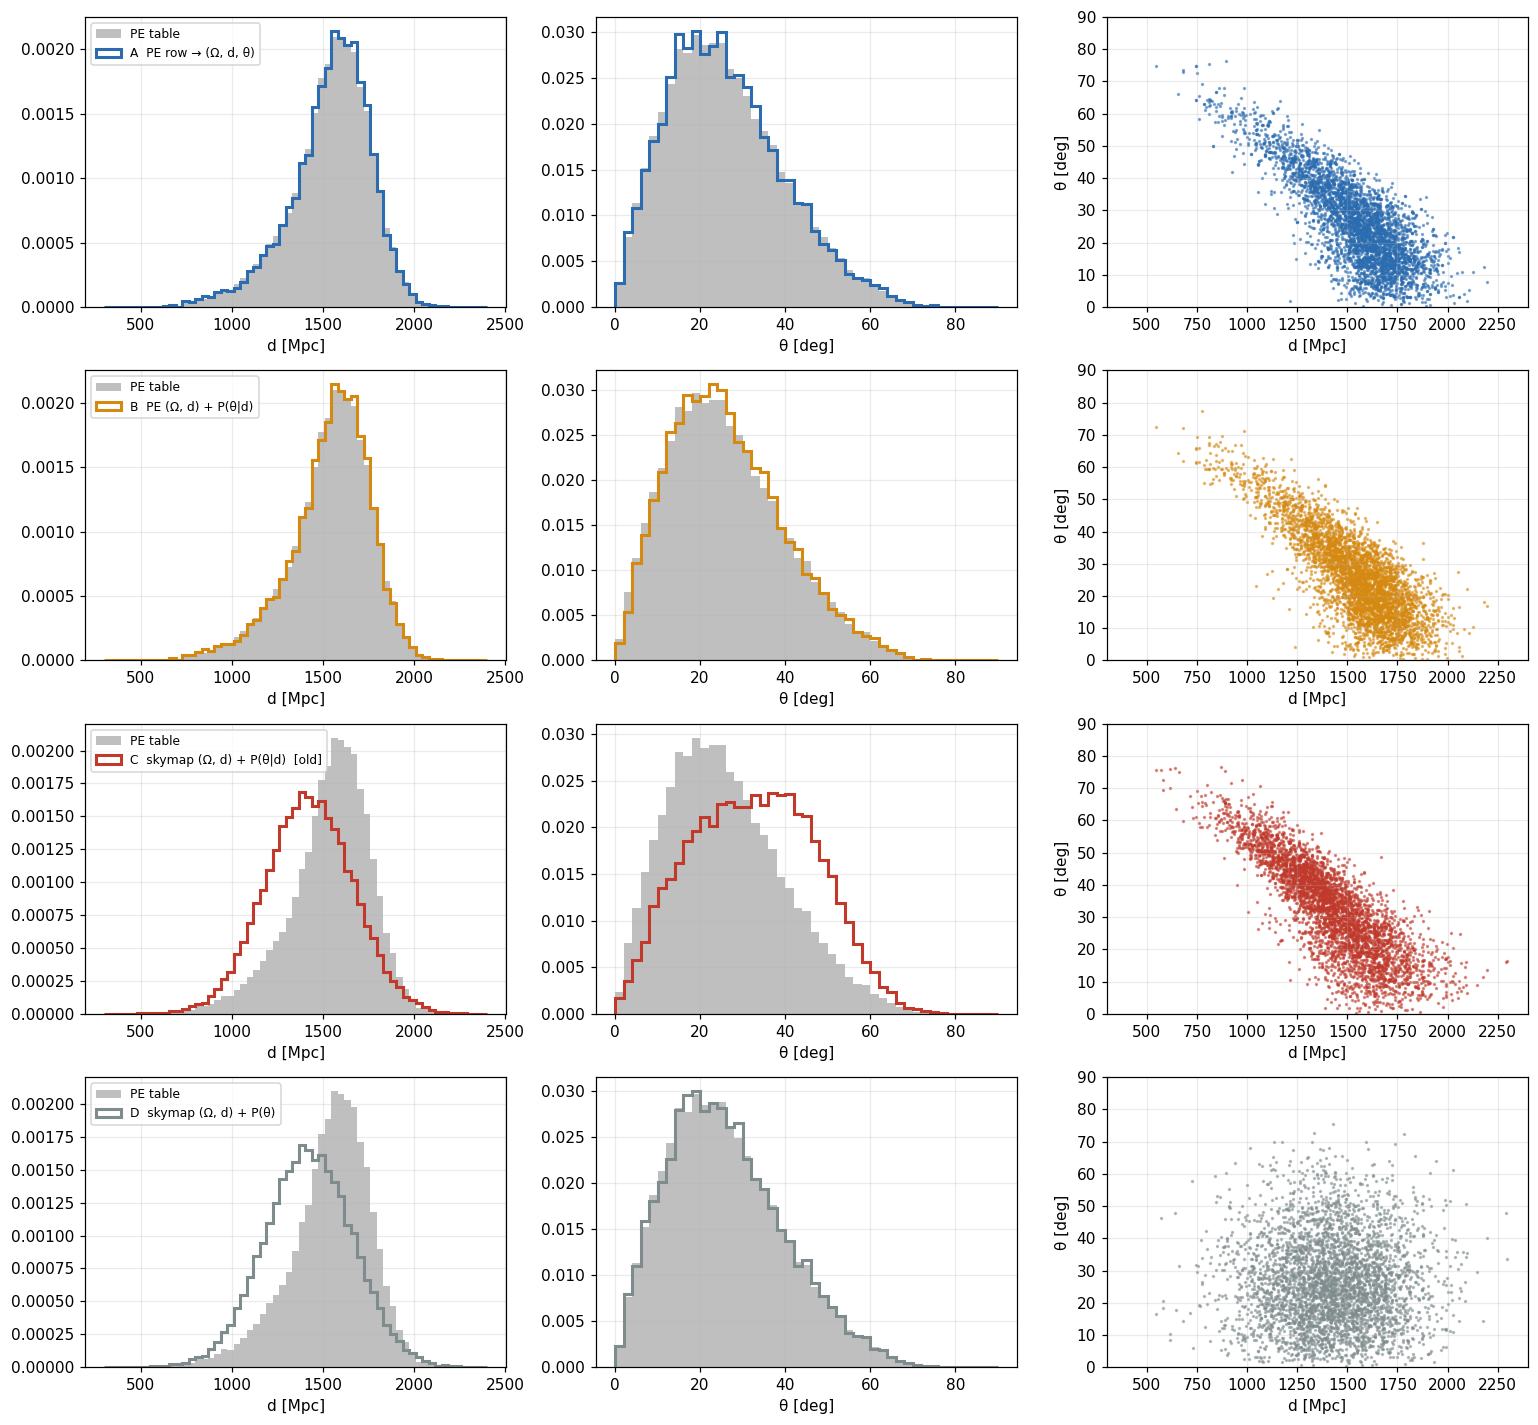

recipe                              d median  θ median  P(θ<20°)  corr(d, cosθ)
PE table (truth)                        1566      24.4     0.373           0.82
A  PE row → (Ω, d, θ)                   1568      24.4     0.376           0.82
B  PE (Ω, d) + P(θ|d)                   1568      24.7     0.361           0.82
C  skymap (Ω, d) + P(θ|d)  [old]        1422      32.5     0.225           0.84
D  skymap (Ω, d) + P(θ)                 1422      24.6     0.371           0.00


In [10]:
def draw_from_skymap(path, n, rng, d_grid=np.linspace(1, 6000, 3000)):
    t = fits.getdata(path, 1)
    uniq = t["UNIQ"].astype(np.int64)
    order = (np.log2(uniq // 4) // 2).astype(int)
    prob = t["PROBDENSITY"] * 4 * np.pi / (12 * 4.0 ** order)          # density x pixel area
    pix = rng.choice(prob.size, size=n, p=prob / prob.sum())           # step 1
    # step 2: inverse CDF of d^2 N(d; mu, sigma), one CDF per *distinct* drawn pixel
    u_pix, inv = np.unique(pix, return_inverse=True)
    pdf = d_grid**2 * np.exp(-0.5 * ((d_grid - t["DISTMU"][u_pix, None]) / t["DISTSIGMA"][u_pix, None])**2)
    cdf = np.cumsum(pdf, axis=1); cdf /= cdf[:, -1:]
    x = rng.random(n)
    d_out = np.array([np.interp(x[i], cdf[inv[i]], d_grid) for i in range(n)])
    nside = 2 ** order[pix]
    ra_s, dec_s = hp.pix2ang(nside, uniq[pix] - 4 * nside**2, nest=True, lonlat=True)
    return ra_s, dec_s, d_out

ra_sky, dec_sky, d_sky = draw_from_skymap(paths.GW_INPUT_DIR / f"{source_name}.fits", N_DRAW, rng)

# P(theta | d): the sky-averaged KDE of the PE samples (what THETA_MODE="gw" loads from its cache)
joint = angdist.JointDistanceAngle.from_samples(d, th)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    k_all = rng.integers(0, n_rows, N_DRAW)
    routes = {
        "A  PE row → (Ω, d, θ)":            (d[k_all], th[k_all], C_PE),
        "B  PE (Ω, d) + P(θ|d)":            (d[k_all], joint.sample_theta_given_distance(d[k_all], rng=rng), C_MID),
        "C  skymap (Ω, d) + P(θ|d)  [old]": (d_sky, joint.sample_theta_given_distance(d_sky, rng=rng), C_OLD),
        "D  skymap (Ω, d) + P(θ)":          (d_sky, th[rng.integers(0, n_rows, N_DRAW)], C_IND),
    }

fig, axs = plt.subplots(4, 3, figsize=(14, 13))
for row, (name, (dd, tt, c)) in zip(axs, routes.items()):
    compare(row, dd, tt, c, name, ref=(d, th))
plt.tight_layout(); plt.show()

print(f"{'recipe':34s} {'d median':>9} {'θ median':>9} {'P(θ<20°)':>9} {'corr(d, cosθ)':>14}")
print(f"{'PE table (truth)':34s} {np.median(d):9.0f} {np.median(th):9.1f} {np.mean(th < 20):9.3f} "
      f"{np.corrcoef(d, np.cos(np.radians(th)))[0, 1]:14.2f}")
for name, (dd, tt, c) in routes.items():
    print(f"{name:34s} {np.median(dd):9.0f} {np.median(tt):9.1f} {np.mean(tt < 20):9.3f} "
          f"{np.corrcoef(dd, np.cos(np.radians(tt)))[0, 1]:14.2f}")

How to read the four rows (grey = the PE table, i.e. the truth):

* **A (new):** matches everywhere, by construction.
* **B:** also matches here. Its $\Omega$ and $d$ come from the PE, and over the **whole sky** the sky-averaged
  $P(\theta\mid d)$ is the right average. Its weakness is local (next section).
* **C (old):** the skymap puts the source **closer** than the final PE. Through the degeneracy,
  closer means **more inclined**, so the angle shifts up by several degrees, and on-axis
  ($\theta<20^\circ$) sources become rarer. The upper limit is then built from fainter, later light curves.
* **D:** the right-hand scatter has no tilt. Far distances are paired with large angles, which the GW data
  rule out. This is what any $d$-independent prior (isotropic, Schutz, fixed, ...) does. It is fine
  only when there is no PE.

---
## 4. The hidden assumption: $P(\theta \mid d, \Omega) \to P(\theta \mid d)$

Recipe B keeps the right $\Omega$ and $d$, but it takes $\theta$ from a $P(\theta\mid d)$ that was
**averaged over the sky**. That is only right if, at a fixed distance, the angle does not depend on where
in the sky the source is. Physically it can: the detectors have different sensitivity to the two
GW polarisations in different directions, so the inclination is measured better in some places than in
others.

Why this matters: **the telescope only looks at part of the localisation.** What enters the limit is the
angle of the sources *inside the observed region*, not the all-sky average.

A **toy** posterior makes this easy to see. It is made up, and the effect is exaggerated on purpose:
two sky patches with the same distances, but sources in patch East are more face-on than in patch West.

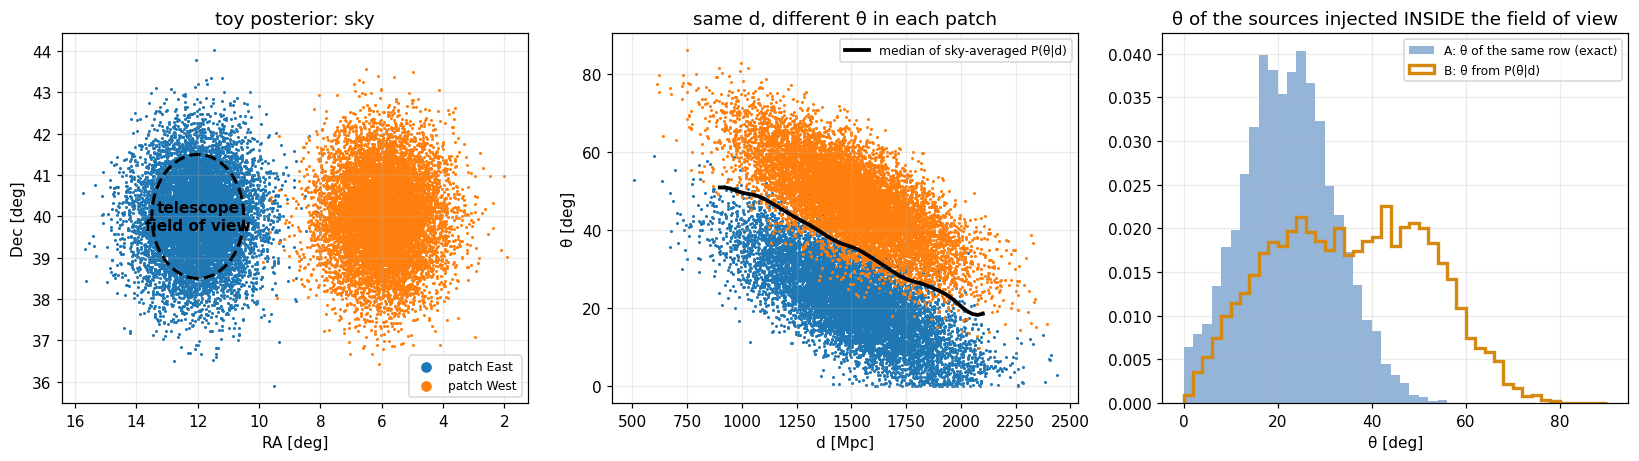

inside the FoV: median θ  exact = 22.3°,  shortcut = 35.6°
whole sky:      median θ  exact = 35.4°,  shortcut = 35.2°


In [11]:
n = 20_000
east = rng.random(n) < 0.5
toy_d = rng.normal(1500, 250, n)
toy_th = np.abs(np.where(east, 22, 48) - 0.03 * (toy_d - 1500) + rng.normal(0, 7, n))
toy_th = np.minimum(toy_th, 180 - toy_th)                          # keep in [0, 90] by folding, like θ_v
toy_ra = np.where(east, 12.0, 6.0) + rng.normal(0, 1.0, n)
toy_dec = 40.0 + rng.normal(0, 1.0, n)

fov_c, fov_r = (12.0, 40.0), 1.5                                   # telescope pointing (only East)
in_fov = np.hypot((toy_ra - fov_c[0]) * np.cos(np.radians(40)), toy_dec - fov_c[1]) < fov_r

toy_joint = angdist.JointDistanceAngle.from_samples(toy_d, toy_th)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    k = rng.integers(0, n, N_DRAW)                                   # Ω and d from the table in both recipes
    th_exact = toy_th[k]                                             # A: θ from the same row
    th_short = toy_joint.sample_theta_given_distance(toy_d[k], rng=rng)   # B: θ from the sky-averaged P(θ|d)
sel = in_fov[k]

fig, axs = plt.subplots(1, 3, figsize=(15, 4.3))
axs[0].scatter(toy_ra[east], toy_dec[east], s=1, c="#1f77b4", label="patch East")
axs[0].scatter(toy_ra[~east], toy_dec[~east], s=1, c="#ff7f0e", label="patch West")
axs[0].add_patch(Circle(fov_c, fov_r, fc="none", ec="k", lw=2, ls="--"))
axs[0].text(*fov_c, "telescope\nfield of view", ha="center", va="center", weight="bold")
axs[0].invert_xaxis(); axs[0].set(xlabel="RA [deg]", ylabel="Dec [deg]", title="toy posterior: sky")
axs[0].legend(markerscale=6, fontsize=8, loc="lower right")

axs[1].scatter(toy_d[east], toy_th[east], s=1, c="#1f77b4")
axs[1].scatter(toy_d[~east], toy_th[~east], s=1, c="#ff7f0e")
d_line = np.linspace(900, 2100, 50)
axs[1].plot(d_line, toy_joint.conditional_theta_quantiles((0.5,), distance_Mpc=d_line)[:, 0], "k-", lw=2.5,
            label="median of sky-averaged P(θ|d)")
axs[1].set(xlabel="d [Mpc]", ylabel="θ [deg]", title="same d, different θ in each patch")
axs[1].legend(fontsize=8)

b = np.linspace(0, 90, 46)
axs[2].hist(th_exact[sel], b, density=True, color=C_PE, alpha=0.5, label="A: θ of the same row (exact)")
axs[2].hist(th_short[sel], b, density=True, histtype="step", lw=2.2, color=C_MID, label="B: θ from P(θ|d)")
axs[2].set(xlabel="θ [deg]", title="θ of the sources injected INSIDE the field of view")
axs[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"inside the FoV: median θ  exact = {np.median(th_exact[sel]):.1f}°,  shortcut = {np.median(th_short[sel]):.1f}°")
print(f"whole sky:      median θ  exact = {np.median(th_exact):.1f}°,  shortcut = {np.median(th_short):.1f}°")

Over the **whole sky** both recipes agree, which is why recipe B looked fine in Section 3. **Inside the
field of view** the shortcut gives every source the sky-averaged angle, so it puts many East sources at
West-like angles. Picking whole rows cannot make this mistake, because each row remembers where it was.

### The same check on real PE

For a well-localised event (S240615dg, a few deg²) the antenna patterns barely change across the
localisation, and the effect is below 1°. For a broad localisation it is not. Below, the PE samples of
**S241125n** (thousands of deg²) are split into 4 sky regions, and the same exact-vs-shortcut comparison
is done per region.

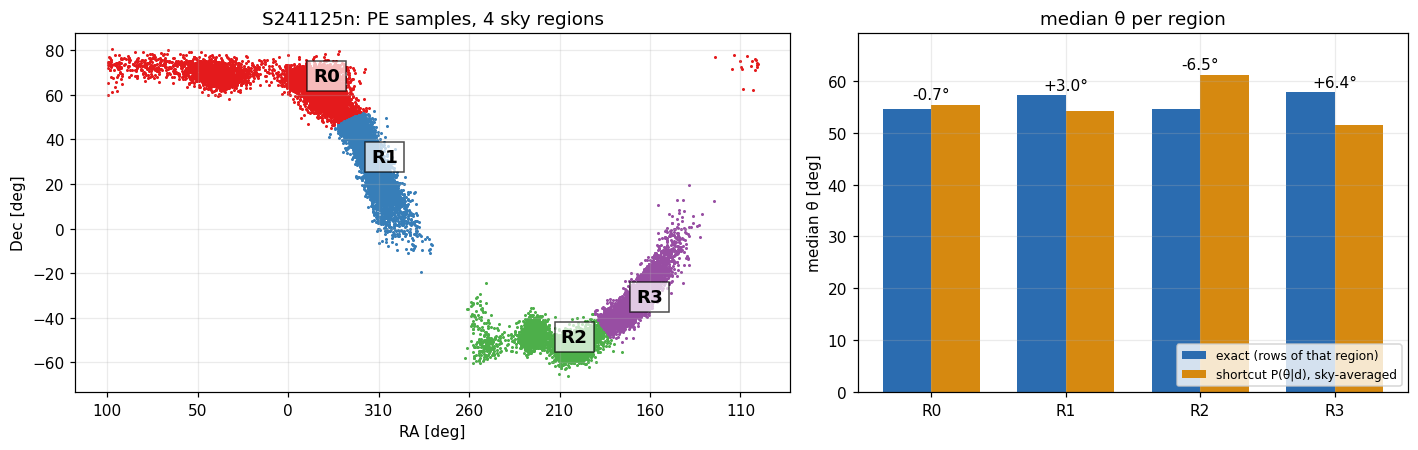

In [12]:
pe2 = gw_pe.load_pe("S241125n")
ra2, dec2, d2, th2 = pe2.get("ra_deg"), pe2.get("dec_deg"), pe2.get("distance_Mpc"), pe2.get("viewing_angle_deg")
regions = angdist.sky_regions(ra2, dec2, n_regions=4)
joint2 = angdist.JointDistanceAngle.from_samples(d2, th2)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    th2_short = joint2.sample_theta_given_distance(d2, rng=rng)    # θ from P(θ|d), at each row's own d

ra2_plot = np.where(ra2 > 100, ra2 - 360, ra2)                    # wrap so that no region is cut in two
fig, axs = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.3, 1]})
cols = plt.cm.Set1(np.arange(4))
for r in range(4):
    m = regions == r
    axs[0].scatter(ra2_plot[m], dec2[m], s=1, color=cols[r])
    axs[0].text(np.median(ra2_plot[m]), np.median(dec2[m]), f"R{r}", weight="bold", fontsize=12,
                bbox=dict(fc="w", alpha=0.7))
axs[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v % 360:.0f}"))
axs[0].invert_xaxis(); axs[0].set(xlabel="RA [deg]", ylabel="Dec [deg]", title="S241125n: PE samples, 4 sky regions")

x = np.arange(4)
med_exact = [np.median(th2[regions == r]) for r in range(4)]
med_short = [np.median(th2_short[regions == r]) for r in range(4)]
axs[1].bar(x - 0.18, med_exact, 0.36, color=C_PE, label="exact (rows of that region)")
axs[1].bar(x + 0.18, med_short, 0.36, color=C_MID, label="shortcut P(θ|d), sky-averaged")
for i in range(4):
    axs[1].text(i, max(med_exact[i], med_short[i]) + 1, f"{med_exact[i] - med_short[i]:+.1f}°", ha="center")
axs[1].set_xticks(x, [f"R{r}" for r in range(4)]); axs[1].set(ylabel="median θ [deg]", title="median θ per region")
axs[1].set_ylim(0, max(med_exact + med_short) + 8); axs[1].legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

The shifts of a few degrees per region are real (the docs, §8.1, test them against a permutation null).
They average out over the whole sky. If the telescope only covered one of these regions, the shortcut
would be biased by that amount.

---
## 5. All the options, in one table

In `sim_3d_model_CTAO_paper_pe_joint.ipynb` two independent switches pick the recipe. They are passed to
`simulate.EmissionModelInjection`, and `simulate.sample_injections_3d` performs the draw.

| `SKY_DISTANCE_MODE` | `THETA_MODE` | where $(\Omega, d)$ come from | where $\theta$ comes from | exact joint? |
|---|---|---|---|---|
| `"pe"` | `"pe"` | one PE row | **the same row** | **yes (default, recipe A)** |
| `"pe"` | `"gw"` | one PE row | $P(\theta\mid d)$, sky-averaged KDE | over the whole sky yes; per region no (recipe B) |
| `"skymap"` | `"gw"` | skymap pixel + its distance ansatz | $P(\theta\mid d)$, sky-averaged KDE | no: skymap $d$ ≠ PE $d$ (recipe C, the old one) |
| `"skymap"` or `"pe"` | `"selection:<D_h>"` | as chosen | population $P(\theta\mid d)$ for a horizon $D_h$ | no event info; keeps a population-level $d$–$\theta$ link |
| `"skymap"` or `"pe"` | `"isotropic"`, `"schutz"`, `"two_bin"`, `"fixed:<deg>"` | as chosen | a prior that ignores $d$ | no (recipe D); use without PE, or as a test |
| `"skymap"` | `"pe"` | — | — | not allowed (`ValueError`): a PE angle needs its own PE row |

Two more details of the default:

* **`sky_mask`**: when the 3D limit is restricted to the 95% region, rows outside it are dropped too
  (Step 1 of Section 2). This conditions the posterior on that region.
* **Reuse**: with $N$ realisations and $M$ kept rows, rows are reused when $N > M$. The function warns if
  fewer than 1000 distinct rows support the draw.

The configuration, in code:

```python
config = simulate.EmissionModelInjection(
    model_dir=...,                 # emission model
    sky_distance="pe",             # (Ω, d) from a PE row
    theta_distribution="pe",       # θ from that same row
    pe_source="S240615dg",         # data/gw_pe/standardized/S240615dg.h5
)
draw = simulate.sample_injections_3d(config, prob_gw, cdf_valid, cdf_table, r_grid, geom,
                                     bin_c_ra, bin_c_dec, n_sim, sampling_seed)
# draw["ra"], draw["dec"], draw["d_sim"], draw["theta_sim"]: one source per realisation
```

---
## Summary

1. The PE posterior is a **table of equally likely sources**. Picking a row at random is a draw from
   $P(\Omega, d, \theta)$, with every correlation kept, and it needs no density estimate.
2. $P(\Omega)\,P(d\mid\Omega)\,P(\theta\mid d,\Omega)$ is the **same** distribution, written as a chain.
   The old recipe broke it in two places. It took $P(\Omega)P(d\mid\Omega)$ from the **skymap** (different
   distances, so through the degeneracy a biased angle: Section 3, recipe C). It used $P(\theta\mid d)$
   instead of $P(\theta\mid d,\Omega)$ (correct on average, biased inside the observed region: Section 4).
3. Without PE there is no event-specific $d$–$\theta$ link at all. Then the options are priors
   (isotropic, Schutz, selection, ...), and the simulation falls back to the skymap.